In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.append('..')
from src.modeling import ModelingData
from sklearn.model_selection import train_test_split

 ### Load cleaned data

In [3]:
df = pd.read_csv('../data/insurance_data_cleaned.csv')
df['TransactionMonth'] = pd.to_datetime(df['TransactionMonth'])

# Create required columns
df['HasClaim'] = (df['TotalClaims'] > 0).astype(int)
df['Margin'] = df['TotalPremium'] - df['TotalClaims']

print(f"Loaded {len(df):,} rows")
print(f"Columns: {df.shape[1]}")
print(f"HasClaim: {df['HasClaim'].sum():,} claims ({df['HasClaim'].mean():.4%})")

Loaded 988,797 rows
Columns: 48
HasClaim: 2,613 claims (0.2643%)


IMPUTE GENDER FROM TITLE

In [4]:
df = ModelingData.impute_gender_from_title(df)
print(df['Gender'].value_counts())

Gender
Male             922262
Female            65725
Not specified       810
Name: count, dtype: int64


Filter to policies with claims

In [5]:
severity_df = df[df['TotalClaims'] > 0].copy()
print(f"Original dataset: {len(df):,} rows")
print(f"Severity dataset: {len(severity_df):,} rows ({len(severity_df)/len(df):.2%} of data)")
print(f"Claims range: R{severity_df['TotalClaims'].min():.2f} to R{severity_df['TotalClaims'].max():.2f}")

Original dataset: 988,797 rows
Severity dataset: 2,613 rows (0.26% of data)
Claims range: R139.04 to R393092.11


### Feature Engineering

In [6]:
severity_df = ModelingData.engineer_features(severity_df)

# Check new features
print("New features created:")
print(f"vehicle_age - min: {severity_df['vehicle_age'].min()}, max: {severity_df['vehicle_age'].max()}")
print(f"policy_duration - min: {severity_df['policy_duration'].min()}, max: {severity_df['policy_duration'].max()}")
print("\nSample data:")
display(severity_df[['RegistrationYear', 'vehicle_age', 'TransactionMonth', 'policy_duration']].head())

New features created:
vehicle_age - min: 0, max: 19
policy_duration - min: 0, max: 638

Sample data:


,RegistrationYear,vehicle_age,TransactionMonth,policy_duration
281,2006,9,2015-03-01,153
1557,2014,1,2015-04-01,122
1776,2009,6,2014-10-01,304
1940,2014,1,2015-04-01,122
2069,2008,7,2015-03-01,153


In [7]:
#  Ensure no missing values
severity_df = ModelingData.handle_missing_values(severity_df)
print(f"Missing values after handling: {severity_df.isnull().sum().sum()}")

Missing values after handling: 0


### Separate Features and Target

In [8]:
# Get X (features) and y (target)
X, y, feature_cols = ModelingData.get_feature_columns(severity_df, target_col='TotalClaims')

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFirst few features: {feature_cols[:5]}")

Features shape: (2613, 37)
Target shape: (2613,)

First few features: ['IsVATRegistered', 'Citizenship', 'LegalType', 'Title', 'Language']


### Identify Column Types

In [9]:
# Identify numerical and categorical columns
numerical_cols, categorical_cols = ModelingData.get_column_types(X)

print(f"Numerical columns: {len(numerical_cols)}")
print(f"Categorical columns: {len(categorical_cols)}")
print(f"\nNumerical: {numerical_cols[:5]}")
print(f"Categorical: {categorical_cols[:5]}")

Numerical columns: 9
Categorical columns: 27

Numerical: ['Cylinders', 'cubiccapacity', 'kilowatts', 'NumberOfDoors', 'CapitalOutstanding']
Categorical: ['Citizenship', 'LegalType', 'Title', 'Language', 'Bank']


### Train/Test Split

In [10]:
# Split data 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {len(X_train):,} policies")
print(f"Test set: {len(X_test):,} policies")
print(f"Train mean claim: R{y_train.mean():.2f}")
print(f"Test mean claim: R{y_test.mean():.2f}")


Training set: 2,090 policies
Test set: 523 policies
Train mean claim: R23745.31
Test mean claim: R21793.82


###  PREPARE DATA FOR EACH MODEL TYPE

In [11]:

# For Random Forest & XGBoost (Label Encoding)
X_train_label, X_test_label, encoders, scaler = ModelingData.prepare_label_encoding_data(
    X_train, X_test, numerical_cols, categorical_cols
)

# For Linear Regression (One-Hot Encoding)
X_train_lr, X_test_lr, onehot, scaler_lr = ModelingData.prepare_onehot_data(
    X_train, X_test, numerical_cols, categorical_cols
)

print(f"Label encoding features: {X_train_label.shape[1]}")
print(f"One-hot encoding features: {X_train_lr.shape[1]}")

Label encoding features: 37
One-hot encoding features: 262


### TRAIN MODELS

In [12]:
# Train Random Forest and XGBoost with hyperparameter tuning
models = ModelingData.train_model(X_train_label, y_train)

# Train Linear Regression (Ridge with auto-tuned alpha)
lr_model = ModelingData.train_linear_regression(X_train_lr, y_train)
models['Linear Regression (Ridge)'] = lr_model

print("\nAll models trained successfully!")

Training Random Forest with tuning...
  Best RF: {'max_depth': 8, 'min_samples_leaf': 15, 'min_samples_split': 10, 'n_estimators': 100}, CV R²: 0.2724
Training XGBoost with tuning...
  Best XGB: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'reg_alpha': 1, 'reg_lambda': 5, 'subsample': 0.7}, CV R²: 0.2655
Best Ridge alpha: 50.0, CV R²: 0.2809

All models trained successfully!


### Evaluate each model 

In [13]:
results = []

# Linear Regression (one-hot data)
lr_result = ModelingData.evaluate_model(lr_model, X_test_lr, y_test, 'Linear Regression (Ridge)')
results.append(lr_result)

# Random Forest (label data)
rf_result = ModelingData.evaluate_model(models['Random Forest'], X_test_label, y_test, 'Random Forest')
results.append(rf_result)

# XGBoost (label data)
xgb_result = ModelingData.evaluate_model(models['XGBoost'], X_test_label, y_test, 'XGBoost')
results.append(xgb_result)

# Create DataFrame
results_df = pd.DataFrame(results)
print(results_df)

                       Model          RMSE        R²
0  Linear Regression (Ridge)  30208.222406  0.296997
1              Random Forest  29770.446639  0.317225
2                    XGBoost  30756.603220  0.271242


SHAP ANALYSIS - SEVERITY MODEL


Generating SHAP analysis for Severity Model...
  Using 523 samples for SHAP analysis


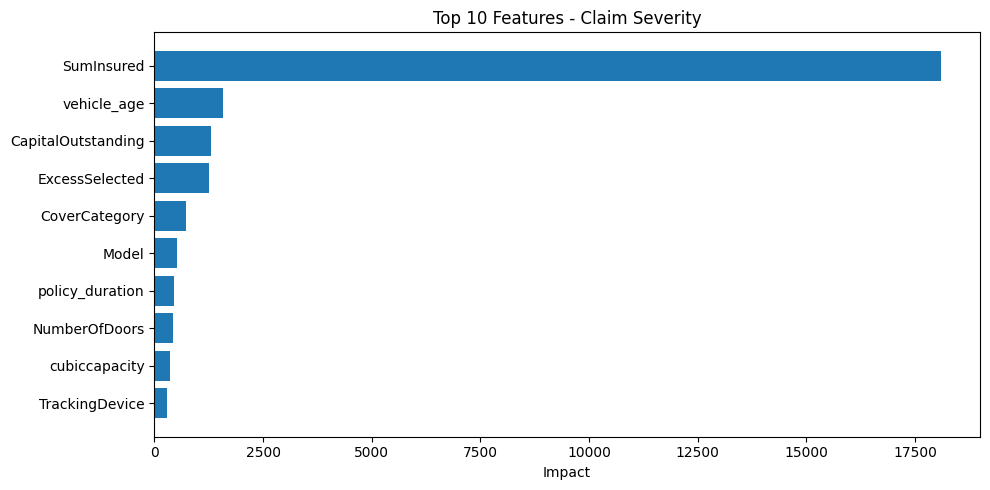

           feature   importance
        SumInsured 18088.200507
       vehicle_age  1587.628530
CapitalOutstanding  1295.575092
    ExcessSelected  1261.032343
     CoverCategory   736.281520
             Model   513.964546
   policy_duration   450.541607
     NumberOfDoors   421.986005
     cubiccapacity   360.290896
    TrackingDevice   286.522876


In [14]:
# Get SHAP feature importance
top_features = ModelingData.shap_analysis(
    models['Random Forest'],
    X_test_label,
    X_train_label.columns.tolist(),
    'Severity Model'
)

# Simple bar chart
plt.figure(figsize=(10, 5))
plt.barh(top_features['feature'], top_features['importance'])
plt.xlabel('Impact')
plt.title('Top 10 Features - Claim Severity')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Print results
print(top_features.to_string(index=False))

### Classification Model (Claim Probability)

In [15]:
# Down-sample (20 non-claims per 1 claim)
balanced_df, w = ModelingData.downsample_data(df, target_col='HasClaim', sampling_ratio=20)

print(f"Original data size: {len(df):,}")
print(f"Balanced data size: {len(balanced_df):,}")
print(f"Claim rate in balanced data: {balanced_df['HasClaim'].mean():.2%}")
print(f"Weight factor (w): {w:.6f}")

Original data size: 988,797
Balanced data size: 54,873
Claim rate in balanced data: 4.76%
Weight factor (w): 0.052992


In [16]:
# Get features from balanced data
X, y, _ = ModelingData.get_feature_columns(balanced_df, target_col='HasClaim')
num_cols, cat_cols = ModelingData.get_column_types(X)

print(f"Features shape: {X.shape}")

# Split first to prevent leakage
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {len(X_train_raw):,}")
print(f"Test set: {len(X_test_raw):,}")


Features shape: (54873, 34)
Training set: 43,898
Test set: 10,975


Encode training and test separately

In [17]:
X_train_enc, X_test_enc, _, _ = ModelingData.prepare_label_encoding_data(
    X_train_raw, X_test_raw, num_cols, cat_cols
)

print(f"Encoded training shape: {X_train_enc.shape}")

Encoded training shape: (43898, 34)


In [18]:
# Train classifier (no class_weight needed because data is balanced)
classifiers = ModelingData.train_classifier(X_train_enc, y_train)

for name, model in classifiers.items():
    results = ModelingData.evaluate_classifier(model, X_test_enc, y_test, name)
    print(f"\n{name}:")
    for metric, value in results.items():
        if metric != 'Model':
            print(f"  {metric}: {value:.4f}")

Training Random Forest Classifier...
Training XGBoost Classifier...

Random Forest Classifier:
  Accuracy: 0.7482
  Precision: 0.1547
  Recall: 0.9598
  F1-Score: 0.2665
  AUC-ROC: 0.8852

XGBoost Classifier:
  Accuracy: 0.7446
  Precision: 0.1518
  Recall: 0.9503
  F1-Score: 0.2618
  AUC-ROC: 0.8867


In [19]:
# Get calibrated probability 
best_model = classifiers['Random Forest Classifier']
p_claim, calibrated_proba = ModelingData.get_claim_probability(
    best_model, 
    X_test_enc, 
    w=w  # Pass the weight factor
)

print(f"Raw probability (biased): {best_model.predict_proba(X_test_enc)[:, 1].mean():.4%}")
print(f"Calibrated probability: {p_claim:.4%}")
print(f"Expected (historical): {df['HasClaim'].mean():.4%}")

Raw probability (biased): 26.3204%
Calibrated probability: 4.3496%
Expected (historical): 0.2643%


 PREMIUM CALCULATION

In [20]:
# Get historical claim probability (the truth)
p_claim = df['HasClaim'].mean()
print(f"Claim Probability: {p_claim:.4%}")

# Get severity from regression model
avg_severity = models['Random Forest'].predict(X_test_label).mean()
print(f"Average Severity: R{avg_severity:,.2f}")

# Calculate premium using YOUR function
premium = ModelingData.calculate_risk_premium(p_claim, avg_severity)

# Compare with current
current = df['CalculatedPremiumPerTerm'].mean()

print("\n" + "="*60)
print("RISK-BASED PRICING RESULT")
print("="*60)
print(f"Claim Probability: {p_claim:.2%}")
print(f"Predicted Severity: R{avg_severity:,.2f}")
print(f"Risk-Based Premium: R{premium:.2f}")
print(f"Current Premium:    R{current:.2f}")
print(f"Difference:         R{premium - current:.2f}")

# Step 5: Recommendation
if premium < current:
    reduction = (current - premium) / current * 100
    print(f"\n RECOMMENDATION: Reduce premiums by {reduction:.0f}%")
    print(f"   New premium: R{premium:.2f} (from R{current:.2f})")
else:
    increase = (premium - current) / current * 100
    print(f"\n RECOMMENDATION: Increase premiums by {increase:.0f}%")
    print(f"   New premium: R{premium:.2f} (from R{current:.2f})")

Claim Probability: 0.2643%
Average Severity: R21,870.30

RISK-BASED PRICING RESULT
Claim Probability: 0.26%
Predicted Severity: R21,870.30
Risk-Based Premium: R75.13
Current Premium:    R115.43
Difference:         R-40.30

 RECOMMENDATION: Reduce premiums by 35%
   New premium: R75.13 (from R115.43)


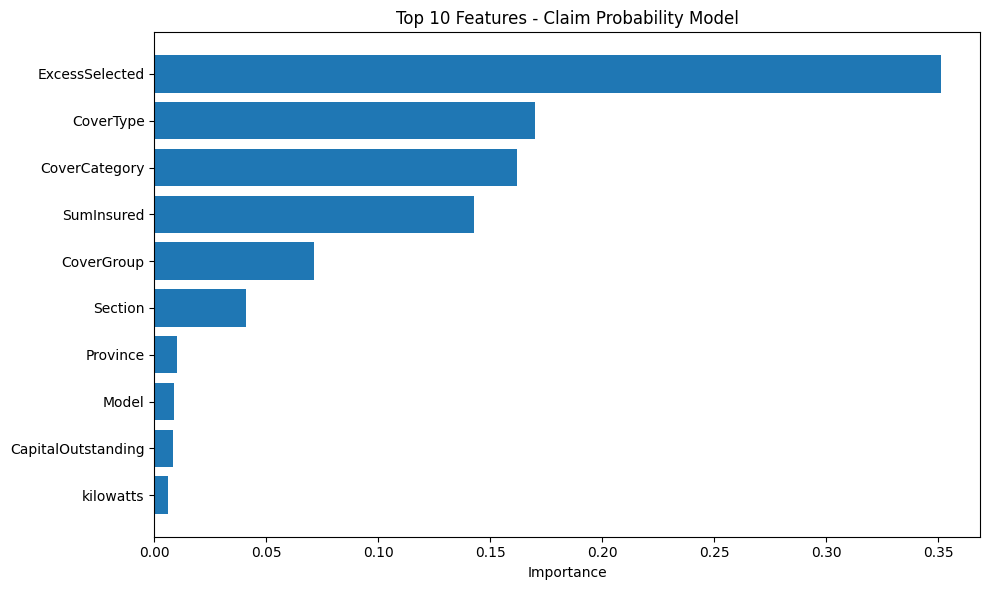


TOP 10 FEATURES - CLAIM PROBABILITY
           feature  importance
    ExcessSelected    0.351118
         CoverType    0.169910
     CoverCategory    0.161874
        SumInsured    0.142574
        CoverGroup    0.071342
           Section    0.040910
          Province    0.009938
             Model    0.008844
CapitalOutstanding    0.008159
         kilowatts    0.006193


In [22]:
### FEATURE IMPORTANCE - CLASSIFIER (Using Built-in Importance)

# Get feature importance from Random Forest Classifier
rf_classifier = classifiers['Random Forest Classifier']
importances_class = rf_classifier.feature_importances_
feature_names = X_train_enc.columns.tolist()

# Create DataFrame
importance_class_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances_class
}).sort_values('importance', ascending=False).head(10)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(importance_class_df['feature'], importance_class_df['importance'])
plt.xlabel('Importance')
plt.title('Top 10 Features - Claim Probability Model')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("TOP 10 FEATURES - CLAIM PROBABILITY")
print("="*60)
print(importance_class_df.to_string(index=False))


In [23]:
print("\n" + "="*60)
print("BUSINESS INTERPRETATION")
print("="*60)

for idx, row in importance_class_df.head(5).iterrows():
    feature = row['feature']
    importance = row['importance']
    
    if 'SumInsured' in feature:
        print(f"\n1. {feature} ({importance:.4f}): Higher coverage → Higher claim probability")
        print("   → Action: Tiered pricing by coverage amount")
    elif 'vehicle_age' in feature:
        print(f"\n2. {feature} ({importance:.4f}): Older vehicles → More claims")
        print("   → Action: Age-based premium adjustments")
    elif 'CapitalOutstanding' in feature:
        print(f"\n3. {feature} ({importance:.4f}): Financed vehicles → Higher risk")
        print("   → Action: Partner with lenders for risk assessment")
    elif 'ExcessSelected' in feature:
        print(f"\n4. {feature} ({importance:.4f}): Lower excess → More frequent claims")
        print("   → Action: Offer premium discounts for higher excess")
    elif 'policy_duration' in feature:
        print(f"\n5. {feature} ({importance:.4f}): Longer policies → More exposure")
        print("   → Action: Factor duration into pricing")
    else:
        print(f"\n• {feature} ({importance:.4f}): Significant predictor of claim probability")


BUSINESS INTERPRETATION

4. ExcessSelected (0.3511): Lower excess → More frequent claims
   → Action: Offer premium discounts for higher excess

• CoverType (0.1699): Significant predictor of claim probability

• CoverCategory (0.1619): Significant predictor of claim probability

1. SumInsured (0.1426): Higher coverage → Higher claim probability
   → Action: Tiered pricing by coverage amount

• CoverGroup (0.0713): Significant predictor of claim probability
